# NEM DER — Data Exploration

Validates NEMOSIS is working and the custom data types look correct.  
Uses a 1-week window to keep download time short.

In [1]:
import sys
sys.path.insert(0, '..')  # allow 'from src...' imports from notebooks/

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from src.data_loader import load_dispatch_price, load_rooftop_pv
from src.models import PriceSeries, RooftopPVSeries

START = '2023-01-09'
END   = '2023-01-16'  # 1 week — fast to download, enough to see duck curve

## 1. Spot Price (DISPATCHPRICE)

In [2]:
price: PriceSeries = load_dispatch_price(START, END)
print(f'Records: {len(price)}')          # expect ~2016 (288 intervals/day × 7 days)
print(f'First record: {price.records[0]}')
print(f'Last record:  {price.records[-1]}')

negative = price.filter_negative()
print(f'Negative price intervals: {len(negative)}')

INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Records: 2016
First record: PriceRecord(settlementdate=datetime.datetime(2023, 1, 9, 0, 5), regionid='SA1', rrp=118.14931)
Last record:  PriceRecord(settlementdate=datetime.datetime(2023, 1, 16, 0, 0), regionid='SA1', rrp=54.71744)
Negative price intervals: 325


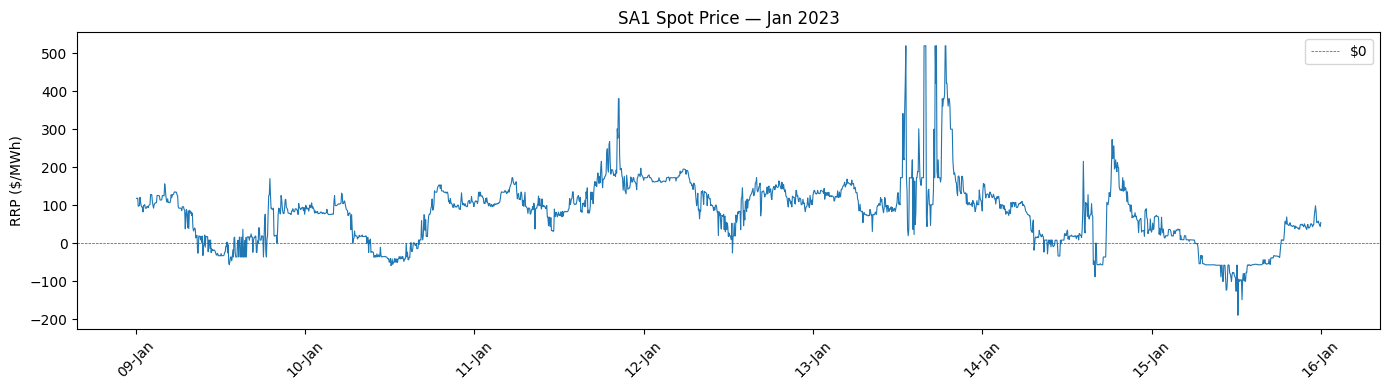

In [3]:
timestamps, rrp_values = price.to_lists()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(timestamps, rrp_values, linewidth=0.8)
ax.axhline(0, color='red', linewidth=0.5, linestyle='--', label='$0')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)
ax.set_title('SA1 Spot Price — Jan 2023')
ax.set_ylabel('RRP ($/MWh)')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Rooftop PV (ROOFTOP_PV_ACTUAL)

In [4]:
solar: RooftopPVSeries = load_rooftop_pv(START, END)
print(f'Records: {len(solar)}')
print(f'Peak output: {solar.peak_mw():.1f} MW')
print(f'First record: {solar.records[0]}')

INFO: Compiling data for table ROOFTOP_PV_ACTUAL
INFO: Returning ROOFTOP_PV_ACTUAL.
Records: 336
Peak output: 1455.3 MW
First record: RooftopPVRecord(settlementdate=datetime.datetime(2023, 1, 9, 0, 30), regionid='SA1', power_mw=0.0)


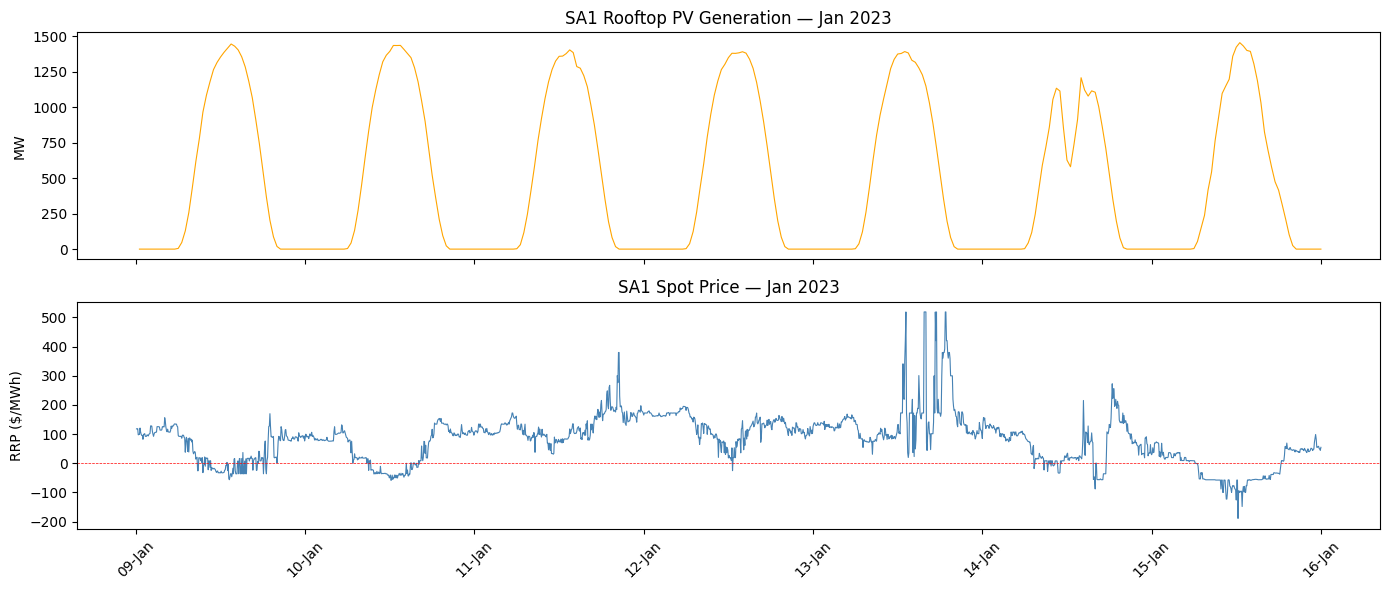

In [5]:
sol_times, sol_power = solar.to_lists()
prc_times, prc_rrp   = price.to_lists()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(sol_times, sol_power, color='orange', linewidth=0.8)
ax1.set_title('SA1 Rooftop PV Generation — Jan 2023')
ax1.set_ylabel('MW')

ax2.plot(prc_times, prc_rrp, color='steelblue', linewidth=0.8)
ax2.axhline(0, color='red', linewidth=0.5, linestyle='--')
ax2.set_title('SA1 Spot Price — Jan 2023')
ax2.set_ylabel('RRP ($/MWh)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax2.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
# Look for: solar peaks midday → price drops/goes negative; solar drops evening → price spikes